In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = Path("recent_dataset_transformed.csv")

if not data_path.exists():
    data_path = Path("crawl_data") / "recent_dataset_transformed.csv"

df = pd.read_csv(data_path)

print("데이터 크기:", df.shape)
df[["views", "scrap_count", "views_log1p", "scrap_count_log1p"]].head()

데이터 크기: (7292, 27)


,views,scrap_count,views_log1p,scrap_count_log1p
0,1217,50,7.104965,3.931826
1,292,1,5.680173,0.693147
2,349,0,5.857933,0.000000
3,1009,40,6.917706,3.713572
4,271,2,5.605802,1.098612


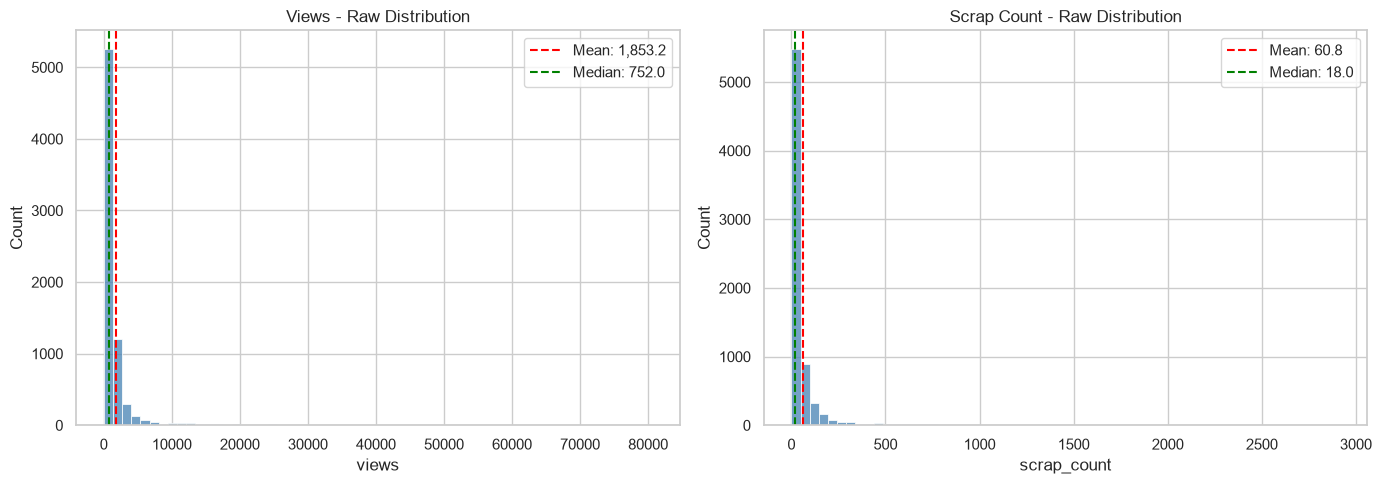

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

columns = ["views", "scrap_count"]
titles = ["Views - Raw Distribution", "Scrap Count - Raw Distribution"]

for ax, column, title in zip(axes, columns, titles):
    sns.histplot(df[column], bins=60, ax=ax, color="steelblue")

    mean_value = df[column].mean()
    median_value = df[column].median()

    ax.axvline(
        mean_value,
        color="red",
        linestyle="--",
        label=f"Mean: {mean_value:,.1f}",
    )
    ax.axvline(
        median_value,
        color="green",
        linestyle="--",
        label=f"Median: {median_value:,.1f}",
    )

    ax.set_title(title)
    ax.set_xlabel(column)
    ax.legend()

plt.tight_layout()
plt.show()

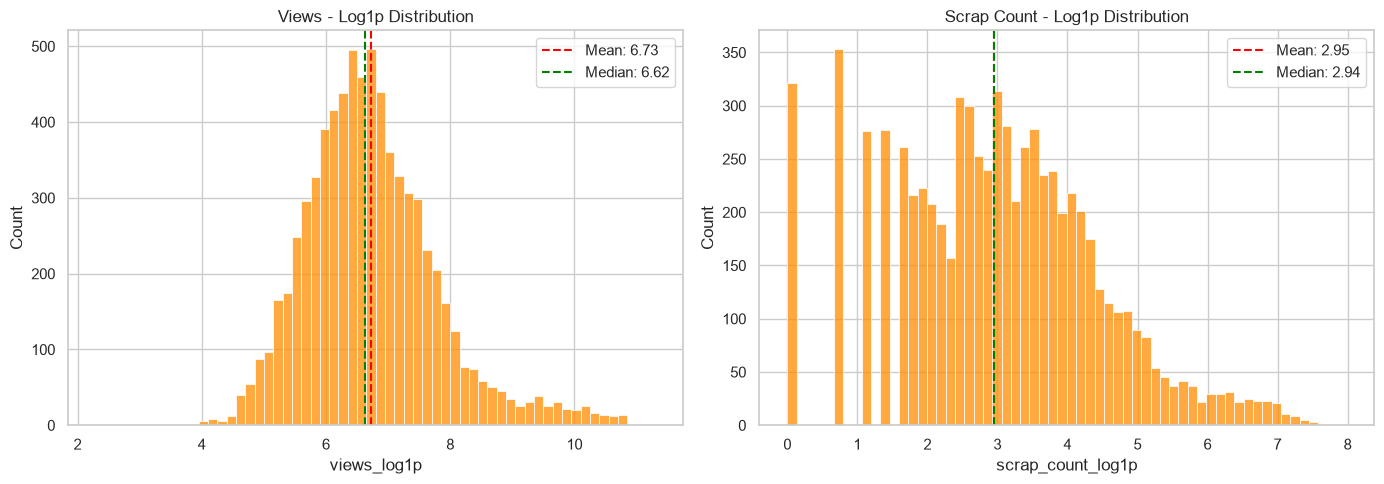

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_columns = ["views_log1p", "scrap_count_log1p"]
titles = [
    "Views - Log1p Distribution",
    "Scrap Count - Log1p Distribution",
]

for ax, column, title in zip(axes, log_columns, titles):
    sns.histplot(df[column], bins=60, ax=ax, color="darkorange")

    mean_value = df[column].mean()
    median_value = df[column].median()

    ax.axvline(
        mean_value,
        color="red",
        linestyle="--",
        label=f"Mean: {mean_value:.2f}",
    )
    ax.axvline(
        median_value,
        color="green",
        linestyle="--",
        label=f"Median: {median_value:.2f}",
    )

    ax.set_title(title)
    ax.set_xlabel(column)
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
distribution_summary = (
    df[
        [
            "views",
            "views_log1p",
            "scrap_count",
            "scrap_count_log1p",
        ]
    ]
    .agg(["mean", "median", "std", "skew"])
    .T
)

distribution_summary["mean_median_ratio"] = (
    distribution_summary["mean"] / distribution_summary["median"]
)

distribution_summary.round(3)

,mean,median,std,skew,mean_median_ratio
views,1853.182,752.000,4476.711,6.692,2.464
views_log1p,6.730,6.624,1.072,0.807,1.016
scrap_count,60.800,18.000,155.482,6.284,3.378
scrap_count_log1p,2.951,2.944,1.480,0.192,1.002


In [8]:
def calculate_distortion(series):
    original_mean = series.mean()

    # 최대값 하나를 제거한 경우
    max_index = series.idxmax()
    mean_without_max = series.drop(index=max_index).mean()

    # 상위 1%를 제거한 경우
    top_1_percent_count = int(np.ceil(len(series) * 0.01))
    top_1_percent_indices = series.nlargest(top_1_percent_count).index
    mean_without_top_1_percent = series.drop(
        index=top_1_percent_indices
    ).mean()

    return pd.Series(
        {
            "median": series.median(),
            "max": series.max(),
            "max_over_median": series.max() / series.median(),
            "max_share_of_total (%)": (
                series.max() / series.sum() * 100
            ),
            "original_mean": original_mean,
            "mean_without_max": mean_without_max,
            "mean_drop_without_max (%)": (
                (original_mean - mean_without_max)
                / original_mean
                * 100
            ),
            "mean_without_top_1%": mean_without_top_1_percent,
            "mean_drop_without_top_1% (%)": (
                (original_mean - mean_without_top_1_percent)
                / original_mean
                * 100
            ),
        }
    )


distortion_summary = pd.DataFrame(
    {
        "views": calculate_distortion(df["views"]),
        "scrap_count": calculate_distortion(df["scrap_count"]),
    }
).T

distortion_summary.round(3)

,median,max,max_over_median,max_share_of_total (%),original_mean,mean_without_max,mean_drop_without_max (%),mean_without_top_1%,mean_drop_without_top_1% (%)
views,752.0,80594.0,107.173,0.596,1853.182,1842.382,0.583,1504.742,18.802
scrap_count,18.0,2914.0,161.889,0.657,60.800,60.409,0.644,49.260,18.980


In [9]:
check_columns = [
    "activity_id",
    "title",
    "organization",
    "views",
    "scrap_count",
    "scrap_rate (%)",
]

top_views = (
    df.nlargest(10, "views")[check_columns]
    .reset_index(drop=True)
)

top_scrap_count = (
    df.nlargest(10, "scrap_count")[check_columns]
    .reset_index(drop=True)
)

print("=== 조회수 상위 10개 공고 ===")
display(top_views)

print("=== 스크랩수 상위 10개 공고 ===")
display(top_scrap_count)

=== 조회수 상위 10개 공고 ===


,activity_id,title,organization,views,scrap_count,scrap_rate (%)
0,329548,2026 Google Student Ambassador,Google,80594,2914,3.6157
1,274937,[SK하이닉스] 2025년 청년 Hy-Po 8기 모집,SK하이닉스 청년 Hy-Po,51321,628,1.2237
2,284623,2025년 SK하이닉스 청년 Hy-Five 인턴 채용 14기,SK하이닉스 청년 Hy-Five,49821,986,1.9791
3,285837,신한투자증권 대학생 서포터즈 모집,신한투자증권,49386,1641,3.3228
4,325605,제45기 신한은행 대학생 홍보대사 모집,(주)신한은행,49256,2042,4.1457
5,299531,[네이버 웨일] 대학생 앰버서더 <웨일 캠퍼스 크루> 모집(~2/22),네이버 주식회사,49057,995,2.0283
6,289843,제44기 신한은행 대학생 홍보대사 모집,(주)신한은행,48574,1527,3.1437
7,295859,[SK하이닉스] 2026 SK하이닉스 대학생 앰버서더 모집(~2/8),SK하이닉스,48514,1474,3.0383
8,293218,KB국민은행 2026년 상반기 청년 디지털 서포터즈 모집 안내,KB국민은행,47619,1077,2.2617
9,325206,2026년 SK하이닉스 청년 Hy-Five 인턴 채용 15기,SK하이닉스 청년 Hy-Five,46216,1055,2.2828


=== 스크랩수 상위 10개 공고 ===


,activity_id,title,organization,views,scrap_count,scrap_rate (%)
0,329548,2026 Google Student Ambassador,Google,80594,2914,3.6157
1,325605,제45기 신한은행 대학생 홍보대사 모집,(주)신한은행,49256,2042,4.1457
2,317602,제20기 하나금융그룹 SMART 홍보대사 모집,하나금융그룹,45830,1890,4.1239
3,307863,"[CJ나눔재단] 2026 CJ도너스캠프 대학생봉사단 모집(~4/13,월)",CJ나눔재단,45979,1796,3.9061
4,319029,"LS그룹, 대학생 해외봉사단 29기 모집(~5/31)",LS그룹,43711,1770,4.0493
5,285837,신한투자증권 대학생 서포터즈 모집,신한투자증권,49386,1641,3.3228
6,282996,[UNIQLO] GLOBAL MANAGEMENT PROGRAM 2026,에프알엘코리아 주식회사 유니클로,39311,1640,4.1719
7,290715,KB-YMCA 대학생경제금융교육봉사단 폴라리스+ 26기 모집,KB국민은행-YMCA,46051,1625,3.5287
8,328005,SK Career Editor,SK그룹,36360,1530,4.2079
9,289843,제44기 신한은행 대학생 홍보대사 모집,(주)신한은행,48574,1527,3.1437


In [10]:
def calculate_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (series < lower_bound)
        | (series > upper_bound)
    )

    return pd.Series(
        {
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_ratio (%)": outlier_mask.mean() * 100,
        }
    )


iqr_summary = pd.DataFrame(
    {
        "views": calculate_iqr_outliers(df["views"]),
        "scrap_count": calculate_iqr_outliers(
            df["scrap_count"]
        ),
    }
).T

iqr_summary.round(3)

,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_ratio (%)
views,409.75,1497.25,1087.5,-1221.5,3128.5,697.0,9.558
scrap_count,6.00,48.00,42.0,-57.0,111.0,791.0,10.848


In [11]:
sanity_check = pd.Series(
    {
        "views 결측치 수": df["views"].isna().sum(),
        "scrap_count 결측치 수": df["scrap_count"].isna().sum(),
        "음수 views 수": (df["views"] < 0).sum(),
        "음수 scrap_count 수": (
            df["scrap_count"] < 0
        ).sum(),
        "scrap_count가 views보다 큰 행 수": (
            df["scrap_count"] > df["views"]
        ).sum(),
        "최대 스크랩 전환율 (%)": (
            df["scrap_rate (%)"].max()
        ),
    }
)

sanity_check

views 결측치 수                   0.0000
scrap_count 결측치 수             0.0000
음수 views 수                    0.0000
음수 scrap_count 수              0.0000
scrap_count가 views보다 큰 행 수    0.0000
최대 스크랩 전환율 (%)                9.4718
dtype: float64

## 이상치 분석 결과 및 처리 결정

### 1. 전체 분포 확인

조회수와 스크랩수 모두 일부 인기 공고로 인해 오른쪽 꼬리가 길게 나타나는 롱테일 분포를 보였다.

- 조회수 평균: 1,853.182
- 조회수 중앙값: 752
- 스크랩수 평균: 60.800
- 스크랩수 중앙값: 18

평균이 중앙값보다 크게 나타나므로 상위 인기 공고들이 전체 평균을 끌어올리고 있음을 확인했다.

### 2. 로그 변환 효과
왜도(skewness)는 데이터 분포가 한쪽으로 얼마나 치우쳐 있는지를 나타내는 통계량이다.

- 왜도가 0에 가까우면 좌우가 비교적 대칭적인 분포이다.
- 왜도가 양수이면 일부 큰 값 때문에 오른쪽 꼬리가 길어진 분포이다.
- 왜도가 음수이면 일부 작은 값 때문에 왼쪽 꼬리가 길어진 분포이다.
- 왜도의 절댓값이 클수록 한쪽으로 치우친 정도가 크다.

원본 조회수와 스크랩수는 일부 인기 공고의 값이 매우 커서 양의 왜도가 크게 나타났다. 로그 변환은 큰 값들의 간격을 압축하므로 이러한 오른쪽 치우침을 완화할 수 있다.
- 조회수 왜도: 6.692 → 0.807
- 스크랩수 왜도: 6.284 → 0.192
- 조회수 평균/중앙값 비율: 2.464 → 1.016
- 스크랩수 평균/중앙값 비율: 3.378 → 1.002

`log1p` 변환 후 왜도와 평균·중앙값의 차이가 크게 감소했으므로 로그 변환이 롱테일 분포 완화에 효과적이라고 판단했다.

### 3. 극단값의 영향

- 최대 조회수: 80,594
- 최대 스크랩수: 2,914
- 최대값 하나를 제거할 경우 평균 감소율: 약 0.6%
- 상위 1%를 제거할 경우 평균 감소율: 약 19%

최대값 하나가 전체 분포를 단독으로 지배하는 것은 아니지만, 인기 공고 집단이 전체 분포의 긴 오른쪽 꼬리를 형성하고 있다.

### 4. IQR 이상치 확인

- 조회수 이상치: 697개, 전체의 9.558%
- 스크랩수 이상치: 791개, 전체의 10.848%

IQR 기준으로 제거하면 전체 데이터의 약 10%에 해당하는 실제 인기 공고가 삭제되므로 적절하지 않다고 판단했다.

### 5. 데이터 오류 확인

- 결측치 없음
- 음수 조회수·스크랩수 없음
- 스크랩수가 조회수보다 큰 행 없음
- 최대 스크랩 전환율: 9.4718%

상위 공고는 Google, 신한은행, 하나금융그룹, CJ, LS그룹 등 실제로 높은 관심을 받을 만한 공고였으며 수집 오류로 볼 근거가 없었다.

### 최종 결정

극단값은 실제 인기 공고의 특성을 나타내는 유효한 데이터이므로 제거하지 않는다. 원본 `views`와 `scrap_count`는 보존하되, 모델링에서는 분포 왜곡을 완화한 `views_log1p`와 `scrap_count_log1p`를 사용한다.